In [ ]:
#Dzisiaj robię "Big Data".
#Nie bede wpisywać ręcznie bazy molekuł tylko wczytam gotowy plik (CSV) zawierający informacje o molekułach.
#Zrobię również wizualizację w postaci wykresu punktowego.

1. Pobieranie danych z internetu...
2. Trwa nauka modelu (TRENING...)
3. Egzamin na ukrytych cząsteczkach...

GOTOWE! Średni błąd (MAE) na cząsteczkach testowych wynosi: 0.704 jednostek LogP



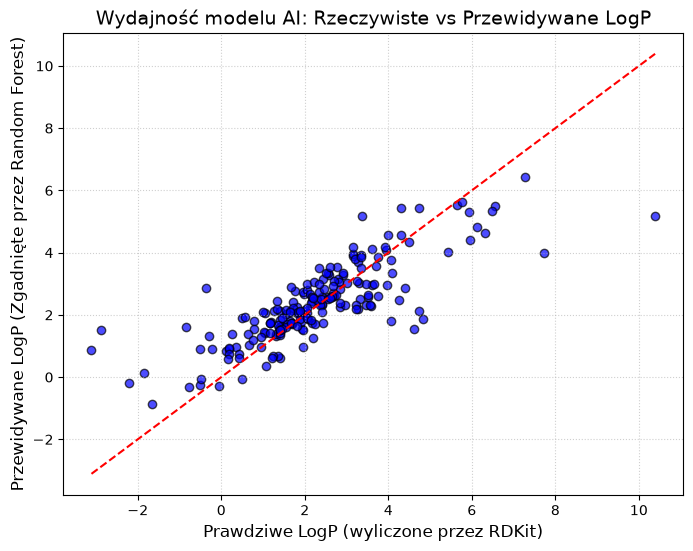

In [6]:
#Importuję potrzebne nam narzędzia rdkit-chemia, pandas-tabele, matplotlib-rysowanie wykresów, sklearn-uczenie maszynowe
import pandas as pd
import matplotlib.pyplot as plt 
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error 

print("1. Pobieranie danych z internetu...")

url = "https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv" 
baza_danych = pd.read_csv(url) #Wczytuję tabele do pamięci jako obiekt "baza danych"

# Pobieram pierwsze 1000 cząsteczek z wczytanej bazy
smiles_list = baza_danych['SMILES'].head(1000).tolist() # .head(1000)-wybiera pierwsze 1000 czasteczek z bazy, zmieniam kolumne z tabelii na zwykła listę pythona

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024) #Definiuję morgan_gen która będzie "ciąć" cząsteczki na 1024 bity
#Tworzę puste listy do których będe wrzucać dane
X_dane_wejsciowe = [] 
Y_cel_do_przewidzenia = []
poprawne_smiles = [] 
#PĘTLA
for sml in smiles_list:
    mol = Chem.MolFromSmiles(sml) #Tworzę tutaj obiekty molekuł, które rdkit rozumie
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol) #Zmieniam obiekty na wektor bitów
        X_dane_wejsciowe.append(list(fp)) #Dodaje fingerprinty do pustej listy (dane dla AI)
        Y_cel_do_przewidzenia.append(Descriptors.MolLogP(mol)) #Tutaj obliczam prawdziwe LogP i dodaje do pustej listy Y_cel_do przewidzenia (Klucz odpowiedzi dla AI)
        poprawne_smiles.append(sml) #do sprawdzenia czy nie ma błedu w pliku albo że coś źle zostało odczytane
#Rozdzielam tutaj dane 0.2 oznacza ze maszyna nie bedzie "znac" własciwosci 20% cząsteczek i bedzie musiała je przewidziec, dzieki randomstate podział przy kazdym urochumieniu jest taki sam
X_trening, X_test, Y_trening, Y_test = train_test_split( 
    X_dane_wejsciowe, #Fingerprinty cząsteczek
    Y_cel_do_przewidzenia, #LogP cząsteczek
    test_size=0.2, # 20%-test 80%-trening
    random_state=42 #ziarno losowości
) #X_trening- 80% fingerprintów model sie uczy na nich Y_trening- 80% wartości LogP (odpowiednei do fingerprintów), X_test- 20% fingerprinty testowe, Y_test- 20% wartości logP poprawne odpowiedzi do testu dzieki nim wiemy czy komputer zgadł dobrze
print("2. Trwa nauka modelu (TRENING...)")
model = RandomForestRegressor(random_state=42) 
model.fit(X_trening, Y_trening) #model.fit- algorytm patrzy na pary (fingerprinty i logP) i buduję w swojej pamięci las drzew decyzyjnych, które kojarzą długość bitu z logp
print("3. Egzamin na ukrytych cząsteczkach...")
przewidywanie = model.predict(X_test) #Tutaj daję AI 200 fingerprintów których algorytm wcześniej nie widział i na podstawie nauki zwraca przwydiwyanie wartości logP
blad_mae = mean_absolute_error(Y_test, przewidywanie) #Porównuje to co zgadło AI z tym co było naprawdę. Błąd mówi mi o ile średnio algorytm sie myli
print(f"\nGOTOWE! Średni błąd (MAE) na cząsteczkach testowych wynosi: {blad_mae:.3f} jednostek LogP\n")
#WYKRES
plt.figure(figsize=(8, 6)) #Tworzę puste okno graficzne 8x6cali
plt.scatter(Y_test, przewidywanie, alpha=0.7, color='blue', edgecolor='black') #Rysuję punkty, ośX=Y_test rzeczywiste wartości ośY=wyniki odgadnięte przez model alpha oznacza przezrotczystość
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--') #Rysowanie lini prostej min i max stosuę aby pasowalo do danych (wykres nie był za duży albo za mały), y=x
#PODPISANIE OSI
plt.title("Wydajność modelu AI: Rzeczywiste vs Przewidywane LogP", fontsize=14)
plt.xlabel("Prawdziwe LogP (wyliczone przez RDKit)", fontsize=12)
plt.ylabel("Przewidywane LogP (Zgadnięte przez Random Forest)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6) #Dodaję kropkowaną siatkę w tle, określam przezroczystość

plt.show() #Wyświetlam
#baza_danych.to_csv("Day9_lokalne.csv", index=False) #Zapis do pliku
#print("pobrane do folderu gdzie jest notatnik")

In [ ]:
#jest to prosty predict pipeline, podsumuję co tu zrobiłem:

   #1. "Przetłumaczyłem" nazwy cząsteczek (SMILES) na wektory 1024 bitów (Fingerprinty).
   #    Obiekty molekuł stały się zbiorem liczb które komputer rozumie i może na nich pracować.

   #2. Wykorzystałem algorytm RandomForestRegressor, który analizuję jakie fragmenty struktur (fingerprinty)
   #   odpowiadają za wzrost lub spadek LogP

   #3. Rozdzieliłem dane na treningowe i testowe. Sprawdziłem czy AI faktycznie nauczyło sie reguł chemicznych

#WNIOSKI
   #1. Na wykresie jesteśmy w stanie zauważyć miejsca w których punkty są blisko lini czerwonej co oznacza
   #   że wyniki przewidziane przez AI oraz prawdziwe są dosyć zbliżone. Obecność tej "chmury" puntków oznacza
   #   że model dosyć poprawnie identyfikuję chemiczne zależności między budową a jej LogP.
   #   
   #2. Wyniki potwierdzają, że Fingerprinty Morgana są wystarczająco bogatą informacją dla algorytmu, aby
   #   odgadnąć fizykochemiczne molekuły bez jej wcześniejszego rysowania.
   #
   #3. Błąd MEA jest miara niepewności w przypadku 1000 czasteczek wynosi 0.704 jednostek LogP.
   #   Taka niedokładność wynika z bazy danych i uczenia sie tego algorytmu. Może też być skustkiem ograniczenia
   #   mocy modelu (może byc niedouczony)
   #
   #4. Można zauważyc ograniczenia zbioru dancyh. Im wyższe LogP tym punkty częściej uciekają tak samo w
   #   w niższych.Model jest tak dobry jak zbiór z którego sie uczy. Prawdopodobnie w tym zbiorze jest mało cząsteczek
   #   hydrofobowych (o wysokim logP) i mocniej hydrofilowych (o małym logP), nie mógł sie nauczyć i zgaduję
   #   je gorzej niż inne o 0<logP<6.

1. Pobieranie danych z internetu...
2. Trwa nauka modelu (TRENING...)
3. Egzamin na ukrytych cząsteczkach...

GOTOWE! Średni błąd (MAE) na cząsteczkach testowych wynosi: 0.484 jednostek LogP



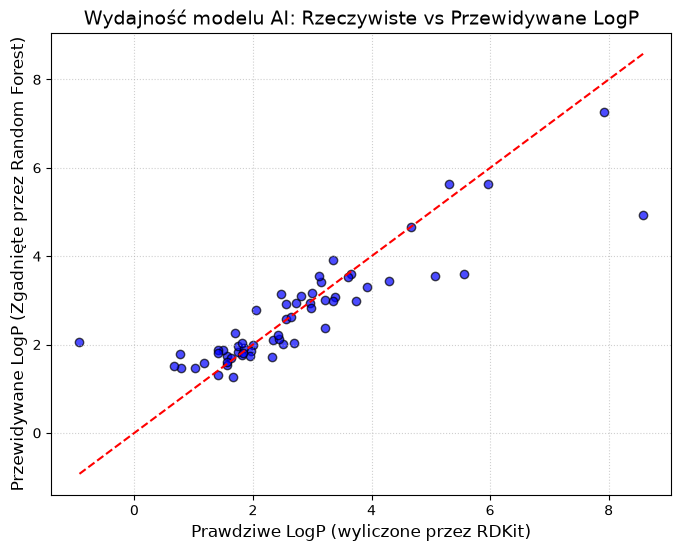

In [1]:
#TEN SAM KOD TYLKO ZMNIEJSZYLEM LICZBE ZWIAZKÓW!!!!
import pandas as pd
import matplotlib.pyplot as plt 
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error 

print("1. Pobieranie danych z internetu...")

url = "https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv" 
baza_danych = pd.read_csv(url)

smiles_list = baza_danych['SMILES'].head(300).tolist()

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
X_dane_wejsciowe = []
Y_cel_do_przewidzenia = []
poprawne_smiles = [] 

for sml in smiles_list:
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol)
        X_dane_wejsciowe.append(list(fp))
        Y_cel_do_przewidzenia.append(Descriptors.MolLogP(mol))
        poprawne_smiles.append(sml)

X_trening, X_test, Y_trening, Y_test = train_test_split(
    X_dane_wejsciowe,
    Y_cel_do_przewidzenia,
    test_size=0.2,
    random_state=42
)

print("2. Trwa nauka modelu (TRENING...)")
model = RandomForestRegressor(random_state=42)
model.fit(X_trening, Y_trening)

print("3. Egzamin na ukrytych cząsteczkach...")
przewidywanie = model.predict(X_test)

blad_mae = mean_absolute_error(Y_test, przewidywanie)
print(f"\nGOTOWE! Średni błąd (MAE) na cząsteczkach testowych wynosi: {blad_mae:.3f} jednostek LogP\n")

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, przewidywanie, alpha=0.7, color='blue', edgecolor='black')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')

plt.title("Wydajność modelu AI: Rzeczywiste vs Przewidywane LogP", fontsize=14)
plt.xlabel("Prawdziwe LogP (wyliczone przez RDKit)", fontsize=12)
plt.ylabel("Przewidywane LogP (Zgadnięte przez Random Forest)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [ ]:
# Przy wyciągnieciu 300 związków, widzę że błąd MEA wynosi 0.484 jednostek LogP, co jest niższym wynikiem
# niż w przypadku 1000 związków. Według mojej logiki im więcej związków do nauczenia tym model powinnien być
# lepszy, aczkolwiek myśle że to przez właśnie powiększenie bazy doszły do "nauczenia się" bardziej skomplikowane
# związki i tutaj model miał problem. Ale też po prostu może w zestawie testowym były cząsteczki, których model
# nie uczył sie na treningu. Może to być spowodowane również wyczerpaniem mocy jak wspominałem wcześniej.
#
# Podkręce troche model.... 

1. Pobieranie danych z internetu...
2. Trwa nauka modelu (TRENING...)
3. Egzamin na ukrytych cząsteczkach...

GOTOWE! Średni błąd (MAE) na cząsteczkach testowych wynosi: 0.737 jednostek LogP



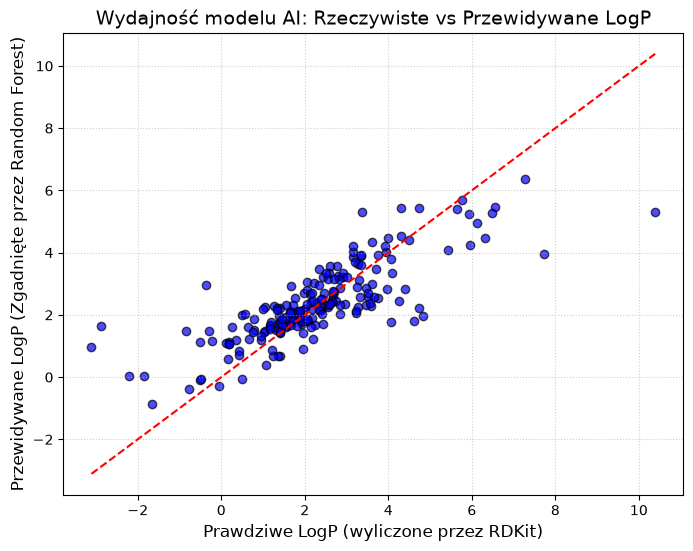

In [6]:
#Dodałem n_estimators=300 oraz max_depth=20 dzięki czemu (prawdopodobnie) model subtelniej zauważy zależności chemii
import pandas as pd
import matplotlib.pyplot as plt 
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error 

print("1. Pobieranie danych z internetu...")

url = "https://raw.githubusercontent.com/dataprofessor/data/master/delaney.csv" 
baza_danych = pd.read_csv(url)

smiles_list = baza_danych['SMILES'].head(1000).tolist()

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
X_dane_wejsciowe = []
Y_cel_do_przewidzenia = []
poprawne_smiles = [] 

for sml in smiles_list:
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol)
        X_dane_wejsciowe.append(list(fp))
        Y_cel_do_przewidzenia.append(Descriptors.MolLogP(mol))
        poprawne_smiles.append(sml)

X_trening, X_test, Y_trening, Y_test = train_test_split(
    X_dane_wejsciowe,
    Y_cel_do_przewidzenia,
    test_size=0.2,
    random_state=42
)

print("2. Trwa nauka modelu (TRENING...)")
model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
model.fit(X_trening, Y_trening)

print("3. Egzamin na ukrytych cząsteczkach...")
przewidywanie = model.predict(X_test)

blad_mae = mean_absolute_error(Y_test, przewidywanie)
print(f"\nGOTOWE! Średni błąd (MAE) na cząsteczkach testowych wynosi: {blad_mae:.3f} jednostek LogP\n")

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, przewidywanie, alpha=0.7, color='blue', edgecolor='black')
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], color='red', linestyle='--')

plt.title("Wydajność modelu AI: Rzeczywiste vs Przewidywane LogP", fontsize=14)
plt.xlabel("Prawdziwe LogP (wyliczone przez RDKit)", fontsize=12)
plt.ylabel("Przewidywane LogP (Zgadnięte przez Random Forest)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

In [7]:
# Niestety otrzymałem jeszcze większy błąd MEA niż wcześniej, pomimo tego że zoptymalizowałem model
# żeby lepiej się uczył.
#
# Pomimo tego, że dałem modelowi więcej mocy obliczeniowej nie uzyskałem lepszych wyników. Może być to spowodowane
# przeuczeniem (overfitting). Model mógł traktować szum jako sztywne reguły. Używajać standardowych parametrów
# dostałem najlepsze wartości błędu MEA, unikając przeuczenia.

SyntaxError: invalid syntax (771094970.py, line 6)